In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score


# Prepare Data
1. Load dataset
2. Copy feature names
3. Convert string labels to binary
4. Train test split
5. Check for missing data
6. Standardize features
7. Drop highly correlated features

In [2]:
# load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
df = pd.read_csv(url)

In [3]:
df.head(4)

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# rename columns based on wdbc.names
columns = [
	'id_number',
	'diagnosis', # M = malignant, B = benign
]

stat_map = {
	0:'mean', 
	1:'standard_error', 
	2:'worst'
}

features = {
	0:'radius', 
	1:'texture', 
	2:'perimeter', 
	3:'area', 
	4:'smoothness', 
	5:'compactness',
	6:'concavity',
	7:'concave_points',
	8:'symmetry',
	9:'fractal_dimension'
}

other_columns = [stat_map[i] + '_' + features[j] for i in range(3) for j in range(10)]

columns.extend(other_columns)

df.columns = columns

From wdbc.names, explanation of columns

Ten real-valued features are computed for each cell nucleus:

	a) radius (mean of distances from center to points on the perimeter)
	b) texture (standard deviation of gray-scale values)
	c) perimeter
	d) area
	e) smoothness (local variation in radius lengths)
	f) compactness (perimeter^2 / area - 1.0)
	g) concavity (severity of concave portions of the contour)
	h) concave points (number of concave portions of the contour)
	i) symmetry 
	j) fractal dimension ("coastline approximation" - 1)

The mean, standard error, and "worst" or largest (mean of the three
largest values) of these features were computed for each image,
resulting in 30 features.  For instance, field 3 is Mean Radius, field
13 is Radius SE, field 23 is Worst Radius.

In [5]:
df.head()

,id_number,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [6]:
# convert 'diagnosis' column to binary
diagnosis = df['diagnosis']
diagnosis = diagnosis.map({"M": 1, "B": 0})

df['diagnosis'] = diagnosis

In [7]:
df

,id_number,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
1,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
2,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
3,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
4,843786,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.470,23.75,103.40,741.6,0.17910,0.52490,0.5355,0.1741,0.3985,0.12440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
564,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
565,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
566,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [8]:
# train test split
X = df.drop(['id_number', 'diagnosis'], axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2
)

In [9]:
X_train

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
461,14.40,26.99,92.25,646.1,0.06995,0.05223,0.034760,0.017370,0.1707,0.05433,...,15.40,31.98,100.40,734.6,0.10170,0.14600,0.14720,0.05563,0.2345,0.06464
472,12.27,29.97,77.42,465.4,0.07699,0.03398,0.000000,0.000000,0.1701,0.05960,...,13.45,38.05,85.08,558.9,0.09422,0.05213,0.00000,0.00000,0.2409,0.06743
440,17.27,25.42,112.40,928.8,0.08331,0.11090,0.120400,0.057360,0.1467,0.05407,...,20.38,35.46,132.80,1284.0,0.14360,0.41220,0.50360,0.17390,0.2500,0.07944
122,14.50,10.89,94.28,640.7,0.11010,0.10990,0.088420,0.057780,0.1856,0.06402,...,15.70,15.98,102.80,745.5,0.13130,0.17880,0.25600,0.12210,0.2889,0.08006
305,13.20,15.82,84.07,537.3,0.08511,0.05251,0.001461,0.003261,0.1632,0.05894,...,14.41,20.45,92.00,636.9,0.11280,0.13460,0.01120,0.02500,0.2651,0.08385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,12.47,18.60,81.09,481.9,0.09965,0.10580,0.080050,0.038210,0.1925,0.06373,...,14.97,24.64,96.05,677.9,0.14260,0.23780,0.26710,0.10150,0.3014,0.08750
393,12.10,17.72,78.07,446.2,0.10290,0.09758,0.047830,0.033260,0.1937,0.06161,...,13.56,25.80,88.33,559.5,0.14320,0.17730,0.16030,0.06266,0.3049,0.07081
97,11.60,12.84,74.34,412.6,0.08983,0.07525,0.041960,0.033500,0.1620,0.06582,...,13.06,17.16,82.96,512.5,0.14310,0.18510,0.19220,0.08449,0.2772,0.08756
221,10.18,17.53,65.12,313.1,0.10610,0.08502,0.017680,0.019150,0.1910,0.06908,...,11.17,22.84,71.94,375.6,0.14060,0.14400,0.06572,0.05575,0.3055,0.08797


In [10]:
# check for missing values
X_train.isna().sum().sum()

np.int64(0)

In [11]:
# standardize columns of training data
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)

X_train.columns = other_columns
X_train

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
461,0.066085,1.806606,0.000600,-0.038092,-1.880301,-0.998156,-0.689415,-0.820324,-0.416117,-1.183227,...,-0.191143,1.026246,-0.216850,-0.265474,-1.388302,-0.704820,-0.621685,-0.922319,-0.903769,-1.074307
472,-0.524567,2.496513,-0.596091,-0.535373,-1.382535,-1.340670,-1.116670,-1.258520,-0.437957,-0.453655,...,-0.586132,2.005077,-0.663368,-0.564533,-1.721380,-1.289933,-1.325411,-1.764518,-0.803113,-0.923163
440,0.861941,1.443132,0.811344,0.739890,-0.935677,0.102956,0.363235,0.188511,-1.289722,-1.219221,...,0.817598,1.587420,0.727482,0.669660,0.477469,0.954464,1.082174,0.868205,-0.659994,-0.272539
122,0.093815,-1.920741,0.082278,-0.052952,0.958521,0.084188,-0.029849,0.199106,0.126246,0.158244,...,-0.130375,-1.553869,-0.146899,-0.246921,-0.070239,-0.500371,-0.101539,0.083990,-0.048197,-0.238952
305,-0.266677,-0.779385,-0.328526,-0.337506,-0.808407,-0.992901,-1.098712,-1.176254,-0.689119,-0.545025,...,-0.391676,-0.833050,-0.461677,-0.431769,-0.894028,-0.775879,-1.271866,-1.386035,-0.422510,-0.033634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,-0.469107,-0.135781,-0.448427,-0.489965,0.219649,0.007240,-0.132730,-0.294590,0.377408,0.118097,...,-0.278243,-0.157382,-0.343635,-0.361983,0.432940,-0.132610,-0.048473,-0.227879,0.148395,0.164099
393,-0.571709,-0.339512,-0.569938,-0.588210,0.449442,-0.147032,-0.528764,-0.419464,0.421088,-0.175393,...,-0.563851,0.029676,-0.568643,-0.563512,0.459657,-0.509720,-0.559057,-0.815890,0.203441,-0.740057
97,-0.710359,-1.469292,-0.720016,-0.680677,-0.474678,-0.566119,-0.600916,-0.413410,-0.732799,0.407434,...,-0.665130,-1.363586,-0.725157,-0.643510,0.455205,-0.461101,-0.406551,-0.485399,-0.232208,0.167350
221,-1.104128,-0.383499,-1.090987,-0.954498,0.675699,-0.382757,-0.899355,-0.775420,0.322807,0.858744,...,-1.047965,-0.447645,-1.046347,-0.876528,0.343882,-0.717287,-1.011220,-0.920502,0.212878,0.189561


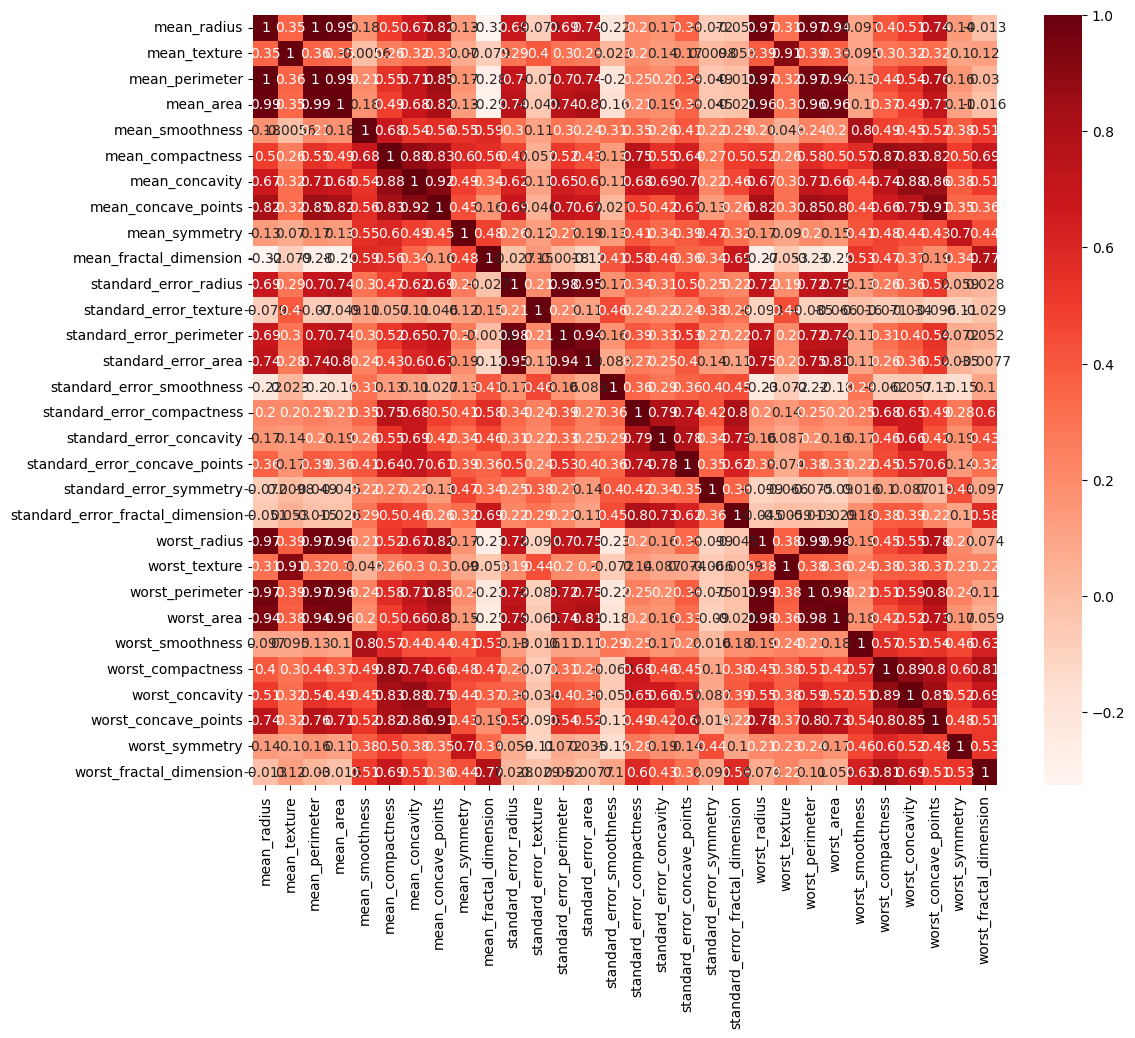

In [12]:
# plot correlation matrix
plt.figure(figsize=(12,10))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=True, cmap=plt.cm.Reds)
plt.show()

In [13]:
# drop highly correlated features
corr_matrix = corr_matrix.abs()

# drop from training set
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_train_light = X_train.drop(to_drop, axis=1)
print(f"Dropped {len(to_drop)} features: {to_drop}")

# drop from test set
X_test_standardized = scaler.transform(X_test)
X_test_light = X_test_standardized.drop(columns=to_drop)

Dropped 10 features: ['mean_perimeter', 'mean_area', 'mean_concave_points', 'standard_error_perimeter', 'standard_error_area', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_concave_points']


# Compare Models

In [14]:
def most_important_feature(model_coef):

    model_coef_weights = pd.Series(
        index = X_test_light.columns,
        data = np.abs(model_coef)
    )

    return model_coef_weights.idxmax()

In [15]:
target_recall = 0.95

def optimal_threshold_for_target_recall(probs, model):
    precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, color='blue', label='Logistic Regression')
    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision')
    plt.title(str(model) + 'Precision-Recall Curve')
    plt.grid(True)
    plt.show()

    # optimal threshold is where recall is at least 95%
    idx = (recalls >= target_recall).argmin() - 1 # (recalls >= target_recall) returns a boolean array
    # and argmin finds the index of the first false. so subtract by one to find index of the last true
    opt_threshold = thresholds[idx] # get optimal threshold
    return opt_threshold

In [16]:
def predict_using_threshold(probs, probability_threshold):
    predictions = (probs >= probability_threshold).astype(int)
    return predictions

In [17]:
def confusion_matrix_and_recall(test_labels, model_predictions):
    cm = confusion_matrix(test_labels, model_predictions)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(cmap='Blues')
    plt.show()

    true_positives = cm[1,1]
    false_positives = cm[0,1]
    false_negatives = cm[1,0]
    true_negatives = cm[0,0]

    actual_positives = true_positives + false_negatives
    actual_negatives = false_positives + true_negatives

    recall = true_positives / actual_positives
    return recall


In [18]:
def evaluate_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1] # get the model's guesses as probabilities, then get only the probabilities of being malignant

    most_important = most_important_feature(model.coef_[0])

    opt_threshold = optimal_threshold_for_target_recall(probs, model)
    predictions = predict_using_threshold(probs, opt_threshold)
    recall = confusion_matrix_and_recall(y_test, predictions)
    ap_score = average_precision_score(y_test, predictions)

    row = {
        'Model':str(model), 
        'Most Important Feature':most_important, 
        'Optimal Threshold':opt_threshold, 
        'Recall':recall, 
        'Average Precision Score':ap_score
    }
    return row

In [19]:
non_regularized_model = LogisticRegression()
l1_log_reg_model = LogisticRegression(penalty='l1', solver='liblinear', C=3)
l2_log_reg_model = LogisticRegression(penalty='l2', C=3)

In [20]:
models = [non_regularized_model, l1_log_reg_model, l2_log_reg_model]

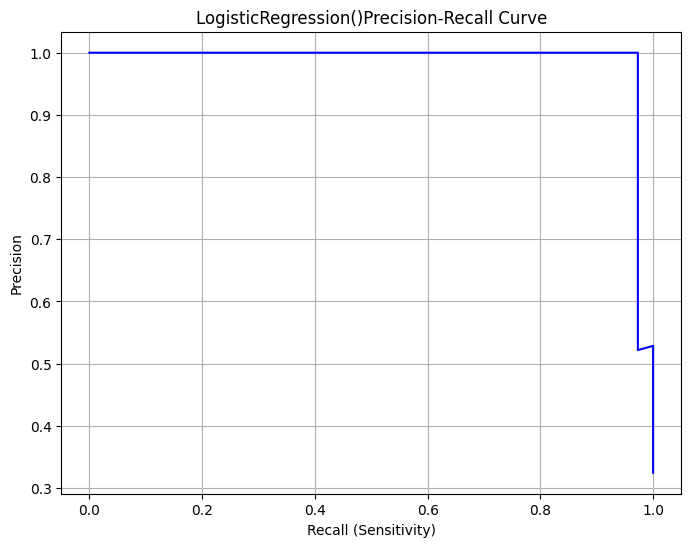

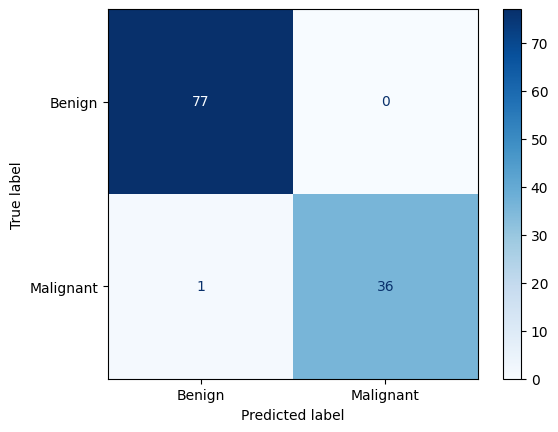

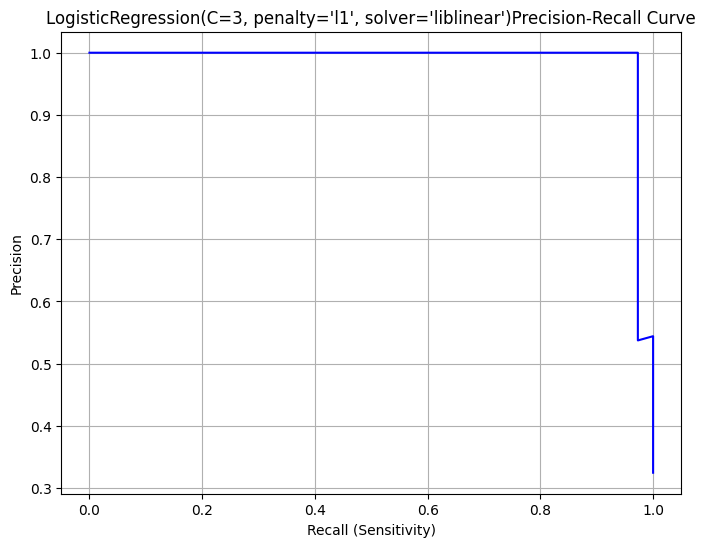

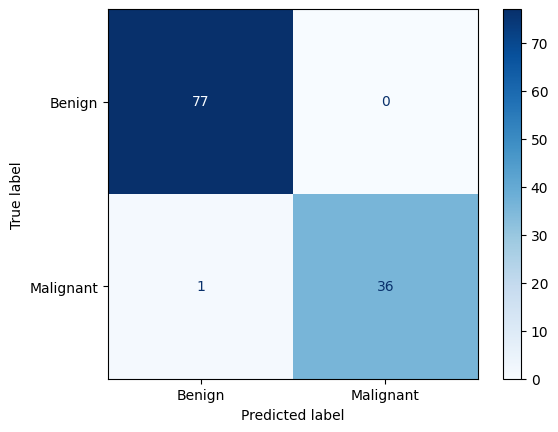

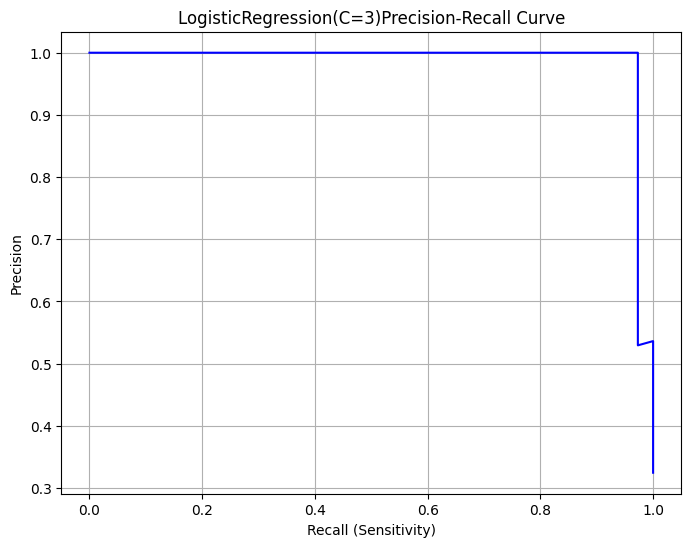

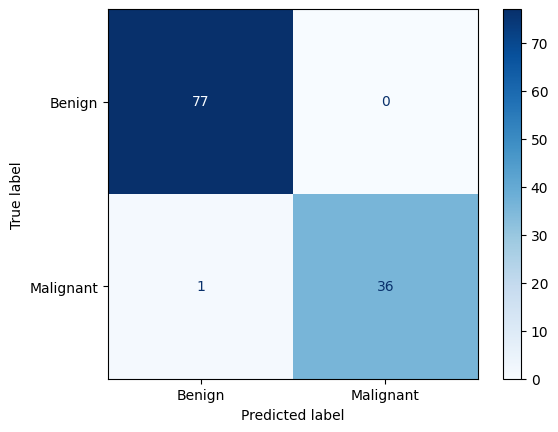

,Model,Most Important Feature,Optimal Threshold,Recall,Average Precision Score
0,LogisticRegression(),mean_radius,0.642506,0.972973,0.981745
1,"LogisticRegression(C=3, penalty='l1', solver='...",mean_radius,0.810962,0.972973,0.981745
2,LogisticRegression(C=3),mean_radius,0.770834,0.972973,0.981745


In [21]:
list_of_rows = []
for model in models:
    list_of_rows.append(evaluate_model(X_train_light, y_train, X_test_light, y_test, model))

evaluation_summary = pd.DataFrame(list_of_rows)
evaluation_summary

Use Precision-Recall Curve to find optimal threshold

# Comparing Features in L1 and L2

In [23]:
nonzero_l1_coefs = np.abs(l1_log_reg_model.coef_[0]) > 0
print(f'L1 uses {nonzero_l1_coefs.sum()} features')

L1 uses 17 features


In [24]:
print(f'L2 uses {l2_log_reg_model.coef_.shape[1]} features')

L2 uses 20 features


In [25]:
# nonzero_l1_coefs # is boolean mask

In [26]:
# X_train_light.columns # is a list of features

In [27]:
l1_removed_features = np.array(X_train_light.columns)[~nonzero_l1_coefs]
print(f'L1 eliminated {l1_removed_features.shape[0]} features: ')
for feature in l1_removed_features:
    print(feature)

L1 eliminated 3 features: 
mean_smoothness
mean_symmetry
worst_compactness
